# Drei Atomiges Molekül

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

## Define Parameters

In [29]:
MODE = 'breathing'
T_SPAN = (0, 20)

root3 = np.sqrt(3)
r_eq = np.array([
    [1, 0],
    [-1/2, root3/2],
    [-1/2, -root3/2]
])

k = 1
m = 1

## Define Forces

In [30]:
r0_eq = root3
sigma = r0_eq / (2**(1/6))
epsilon = 1.0

def F_LJ(r_vec, epsilon=epsilon, sigma=sigma):
    r = np.linalg.norm(r_vec)
    if r < 1e-10:
        return np.zeros(2)
    return 24 * epsilon * (2*(sigma/r)**13 - (sigma/r)**7) * (r_vec / r)

In [31]:
def compute_forces(positions):
    x1, y1, x2, y2, x3, y3 = positions
    
    r12_vec = np.array([x1-x2, y1-y2])
    r13_vec = np.array([x1-x3, y1-y3])
    r23_vec = np.array([x2-x3, y2-y3])
    
    F12_vec = F_LJ(r12_vec)
    F13_vec = F_LJ(r13_vec)
    F23_vec = F_LJ(r23_vec)
    
    forces = np.array([
        F12_vec[0] + F13_vec[0],
        F12_vec[1] + F13_vec[1],
        -F12_vec[0] + F23_vec[0],
        -F12_vec[1] + F23_vec[1],
        -F13_vec[0] - F23_vec[0],
        -F13_vec[1] - F23_vec[1]
    ])
    
    return forces

def equations_of_motion(t, y):
    pos = y[:6]
    vel = y[6:]
    
    forces = compute_forces(pos)
    
    a = forces / m
    dydt = np.concatenate([vel, a]) 
    return dydt

## Define Initial Conditions

In [32]:
def create_initial_conditions(mode='breathing',r_eq=r_eq, amplitude=0.05):
    positions_0 = r_eq.copy()
    velocities_0 = np.zeros_like(positions_0)
    
    if mode == 'breathing':
        u4 = np.array([2, 0, -1, root3, -1, -root3]) / np.sqrt(12)
        positions_0 = r_eq + amplitude * u4.reshape(3, 2)
        
    elif mode == 'rotation':
        omega = amplitude * 2
        for i in range(3):
            tangent = np.array([-r_eq[i, 1], r_eq[i, 0]])
            tangent = tangent / np.linalg.norm(tangent)
            velocities_0[i] = omega * tangent
            
    elif mode == 'mode5':
        u5 = np.array([2, 0, -1, -root3, -1, root3]) / np.sqrt(12)
        positions_0 = r_eq + amplitude * u5.reshape(3, 2)
        
    elif mode == 'mode6':
        u6 = np.array([-1, root3, 2, 0, -1, -root3]) / np.sqrt(12)
        positions_0 = r_eq + amplitude * u6.reshape(3, 2)
        
    return positions_0, velocities_0

## Solve IVP

In [38]:
mode = MODE
positions_0, velocities_0 = create_initial_conditions(mode=mode, amplitude=0.08)

y0 = np.concatenate([positions_0.flatten(), velocities_0.flatten()])

t_span = T_SPAN
t_eval = np.linspace(min(t_span), max(t_span), 1000)

solution = solve_ivp(equations_of_motion, t_span, y0, t_eval=t_eval, 
                     method='RK45', rtol=1e-9, atol=1e-11)

positions_t = solution.y[:6].T.reshape(-1, 3, 2)

colors = ['crimson', 'blue', 'rebeccapurple']

## Annimation

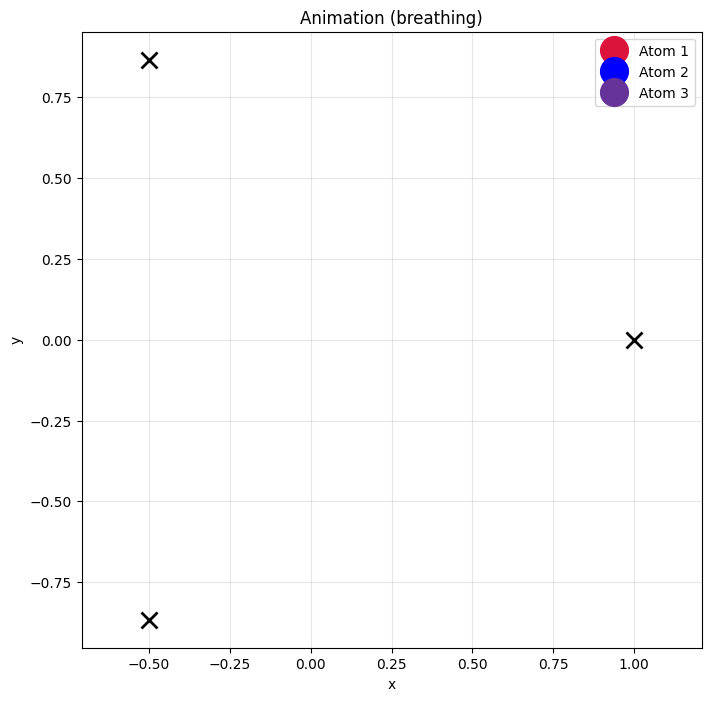

In [40]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Animation ({mode})')
ax.axis('equal')
ax.grid(True, alpha=0.3)

for i in range(3):
    ax.plot(r_eq[i, 0], r_eq[i, 1], 'kx', markersize=12, markeredgewidth=2)

atoms = []
trails = []
for i in range(3):
    atom, = ax.plot([], [], 'o', color=colors[i], markersize=20, label=f'Atom {i+1}')
    trail, = ax.plot([], [], '-', color=colors[i], alpha=0.3, linewidth=1)
    atoms.append(atom)
    trails.append(trail)

lines = []
for i in range(3):
    j = (i + 1) % 3
    line, = ax.plot([], [], 'k-', linewidth=2, alpha=0.5)
    lines.append(line)

time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=12)
ax.legend(loc='upper right')

trail_length = 150

def init():
    for atom in atoms:
        atom.set_data([], [])
    for trail in trails:
        trail.set_data([], [])
    for line in lines:
        line.set_data([], [])
    time_text.set_text('')
    return atoms + trails + lines + [time_text]

def animate(frame):
    for i, atom in enumerate(atoms):
        atom.set_data([positions_t[frame, i, 0]], [positions_t[frame, i, 1]])
    
    start = max(0, frame - trail_length)
    for i, trail in enumerate(trails):
        trail.set_data(positions_t[start:frame+1, i, 0], 
                      positions_t[start:frame+1, i, 1])
    
    for i, line in enumerate(lines):
        j = (i + 1) % 3
        line.set_data([positions_t[frame, i, 0], positions_t[frame, j, 0]],
                     [positions_t[frame, i, 1], positions_t[frame, j, 1]])
    
    time_text.set_text(f'Zeit: {solution.t[frame]:.2f}')
    
    return atoms + trails + lines + [time_text]

anim = FuncAnimation(fig, animate, init_func=init, frames=len(solution.t), 
                    interval=30, blit=True, repeat=True)

In [ ]:
K = k/4 * np.array([
    [6, 0, -3 ,root3, -3, -root3],
    [0, 2, root3, -1, -root3, -1],
    [-3, root3, 3, -root3, 0, 0],
    [root3, -1, -root3, 5, 0, -4],
    [-3, -root3, 0, 0, 3, root3],
    [-root3, -1, 0, -4, root3, 5]
], dtype=np.float64)

lam = np.linalg.eigvals(K)